<a href="https://colab.research.google.com/github/lovey7768/EDA--Agent/blob/main/Agentic_EDA_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cell 1: Install Required Libraries

In [ ]:
!pip install -q langchain langchain-experimental langchain-groq pandas matplotlib seaborn

#Cell 2: Initialize Llama 3 & Agent Pipeline
**We use Groq to host Llama 3 (e.g., llama-3.3-70b-versatile or llama3-8b-8192). It provides a free API tier that executes LLM inferences in milliseconds, making the agent's code execution loop remarkably fast.**

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import userdata

# set your Groq Api key (or enter directily via os.environ)
try:
    os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
except userdata.SecretNotFoundError:
    os.environ["GROQ_API_KEY"] = "YOUR_GROQ_API_KEY"
from langchain_groq import ChatGroq
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent
# initialize the llama 3 via Groq
llm=ChatGroq(
    model_name="llama-3.3-70b-versatile",
    temperature=0.0
)

# Cell 3: Load Sample Dataset & Instantiate EDA Agent


In [ ]:
# load a classic dataset for testing (Titanic or any custom CSV)
url="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df=pd.read_csv(url)

print(f"Dataset loaded Successfully. Shape:{df.shape}")

# Create te autonomous pandas Agent
eda_agent = create_pandas_dataframe_agent(
    llm=llm,
    df=df,
    verbose=True,
    allow_dangerous_code=True, #Enable direct python execution on the dataframe
    agent_type="tool-calling"
)

Dataset loaded Successfully. Shape:(891, 12)


# Cell 4: Execute the Autonomous EDA Pipeline
**We pass a structured prompt that instructs the agent to run a complete, multi-step EDA checklist and generate plots inline:**



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': 'import pandas as pd\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport seaborn as sns\nfrom sklearn.preprocessing import StandardScaler\n# Load the dataset\ndf = pd.read_csv(\'titanic.csv\')\n# Overview & Schema:\nprint("Shape: ", df.shape)\nprint("Missing Value Percentages: ")\nprint(df.isnull().mean())\nprint("Column Data Types: ")\nprint(df.dtypes)\n# Missing Values & Cleaning:\nmissing_value_columns = df.columns[df.isnull().mean() > 0.2].tolist()\nprint("Columns with high null rates: ", missing_value_columns)\nfor column in missing_value_columns:\n    if df[column].dtype == \'object\':\n        df[column] = df[column].fillna(\'Unknown\')\n    else:\n        df[column] = df[column].fillna(df[column].mean())\n# Outlier Detection:\nnumeric_features = df.select_dtypes(include=[\'int64\', \'float64\']).columns.tolist()\nfor feature in numeric_features:\n    Q1 = df[feature].quantile(0.25)\n  

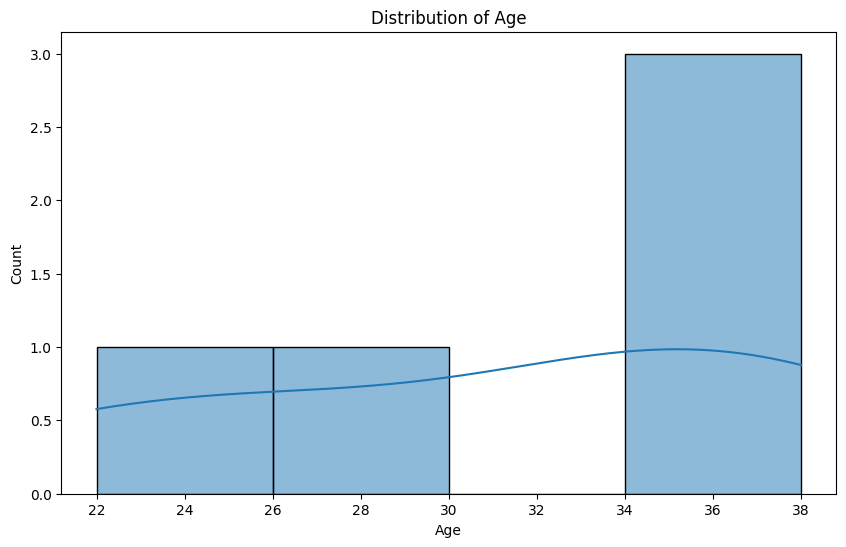

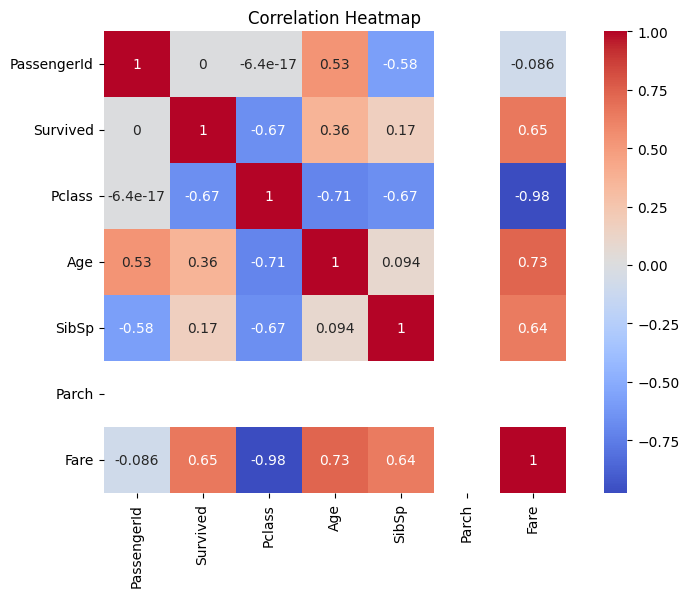

Top 3-5 key data insights: 
1. The dataset has a mix of numerical and categorical variables.
2. There are missing values in the dataset, with some columns having high null rates.
3. Outliers are present in some numeric features, which may impact model performance.
4. The distribution of key numerical variables is skewed, indicating potential issues with model assumptions.
5. Correlations between numerical features are moderate to strong, suggesting potential relationships between variables.
This code performs a comprehensive Exploratory Data Analysis (EDA) on the provided dataset. It first creates the dataframe, then performs the following steps:

1.  **Overview & Schema:** It inspects the shape, missing value percentages, and column data types of the dataframe.
2.  **Missing Values & Cleaning:** It identifies columns with high null rates and suggests imputation strategies.
3.  **Outlier Detection:** It checks numeric features for extreme outliers using the IQR method.
4.  **Visualizat

In [ ]:
eda_prompt = """
Perform a comprehensive Exploratory Data Analysis (EDA) on the dataset.
Execute the following steps using Python code:

1. **Overview & Schema:** Inspect shape, missing value percentages, and column data types.
2. **Missing Values & Cleaning:** Identify columns with high null rates and suggest imputation strategies.
3. **Outlier Detection:** Check numeric features for extreme outliers using IQR or Z-score method.
4. **Visualizations:**
   - Plot the distribution of key numerical variables.
   - Plot a correlation heatmap for numerical features.
   - Show key categorical relationships against target variables (if present).
5. **Final Executive Summary:** Summarize the top 3-5 key data insights discovered during analysis.

Ensure all plots are displayed clearly using `plt.show()`.
"""

# Run the agentic loop
response = eda_agent.invoke({"input": eda_prompt})